In [27]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env in cwd or parent dirs
import wandb


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()

### Retrieve data and build dataframse

In [29]:
from collections import defaultdict
import re

PROJECT_PATH = "jdm8943-rochester-institute-of-technology/imgs789_inference"

runs = api.runs(PROJECT_PATH)

rows_transformer = []
rows_graph       = []

for run in runs:
    if run.state != "finished":
        continue

    is_transformer = run.name.startswith("infer_transformer")
    is_graph       = run.name.startswith("infer_graph")

    if not is_transformer and not is_graph:
        continue

    datasource_data = defaultdict(dict)

    for k, v in run.summary.items():
        if k.startswith("_"):
            continue
        parts = k.split("/")

        if is_transformer:
            if k.startswith("transformer/") and len(parts) == 3:
                datasource_data[parts[1]][parts[2]] = v
        elif is_graph:
            if k.startswith("test/") and len(parts) == 3:
                datasource_data[parts[1]][parts[2]] = v

    for datasource, metrics in datasource_data.items():
        row = {
            "run_name":        run.name,
            "test_datasource": datasource,
            **metrics,
        }
        if is_transformer:
            rows_transformer.append(row)
        else:
            rows_graph.append(row)

transformer_df  = pd.DataFrame(rows_transformer)
graph_df = pd.DataFrame(rows_graph)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)


In [30]:
transformer_df

,run_name,test_datasource,bertscore_f1,bertscore_f1_std,bertscore_precision,bertscore_precision_std,bertscore_recall,bertscore_recall_std,chrf,chrf_std,dist1,dist2,inference_time_s,mean_cosine_sim,meteor,meteor_std,pred_semantic_sim,rougeL,rougeL_std,tag_f1_accent,tag_f1_accent_std,tag_f1_gender,tag_f1_gender_std,tag_f1_intrinsic_tags,tag_f1_intrinsic_tags_std,tag_f1_noise,tag_f1_noise_std,tag_f1_overall,tag_f1_overall_std,tag_f1_pitch,tag_f1_pitch_std,tag_f1_situational_tags,tag_f1_situational_tags_std,tag_f1_speaking_rate,tag_f1_speaking_rate_std,vec_norm_cv,vec_std,tag_f1_emotion,tag_f1_emotion_std,tag_f1_volume,tag_f1_volume_std
0,infer_transformer_expresso,expresso,0.922173,0.012623,0.920085,0.012969,0.924361,0.015335,0.524853,0.082216,0.033135,0.105627,36.602778,0.433376,0.413948,0.126038,0.841544,0.409421,0.092134,0.9,0.3,0.715,0.451414,0.528457,0.340976,0.543333,0.497002,0.652508,0.193614,0.96,0.195959,0.454405,0.35858,0.420000,0.493559,0.003174,0.715522,NaN,NaN,NaN,NaN
1,infer_transformer_styletalk,styletalk,0.919473,0.013168,0.898964,0.016373,0.941046,0.012831,0.651609,0.085052,0.020038,0.045605,28.206986,0.763677,0.594861,0.123606,0.827974,0.487114,0.082318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.715417,0.264242,NaN,NaN,NaN,NaN,0.716667,0.448144,0.009192,0.397680,0.605833,0.446958,0.835,0.371181


In [31]:
graph_df

,run_name,test_datasource,bertscore_f1,bertscore_f1_std,bertscore_precision,bertscore_precision_std,bertscore_recall,bertscore_recall_std,chrf,chrf_std,dist1,dist2,inference_time_s,mean_cosine_sim,meteor,meteor_std,pred_semantic_sim,rougeL,rougeL_std,tag_f1_accent,tag_f1_accent_std,tag_f1_gender,tag_f1_gender_std,tag_f1_intrinsic_tags,tag_f1_intrinsic_tags_std,tag_f1_noise,tag_f1_noise_std,tag_f1_overall,tag_f1_overall_std,tag_f1_pitch,tag_f1_pitch_std,tag_f1_situational_tags,tag_f1_situational_tags_std,tag_f1_speaking_rate,tag_f1_speaking_rate_std,vec_norm_cv,vec_std,tag_f1_emotion,tag_f1_emotion_std,tag_f1_volume,tag_f1_volume_std
0,infer_graph_expresso,expresso,0.920518,0.012574,0.917974,0.012064,0.923158,0.015696,0.516267,0.079726,0.023944,0.065261,36.378416,0.465382,0.421826,0.120229,0.844235,0.408241,0.090036,0.95,0.217945,0.845,0.361905,0.548385,0.310583,0.55,0.497494,0.650485,0.164137,0.96,0.195959,0.309643,0.345044,0.365,0.481430,0.099485,0.228814,NaN,NaN,NaN,NaN
1,infer_graph_styletalk,styletalk,0.916854,0.010762,0.899055,0.011060,0.935423,0.012458,0.605018,0.075582,0.007305,0.017846,27.862047,0.755273,0.591351,0.107265,0.879245,0.466349,0.057795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.679286,0.288183,NaN,NaN,NaN,NaN,0.710,0.453762,0.081478,0.157016,0.495,0.493263,0.835,0.371181


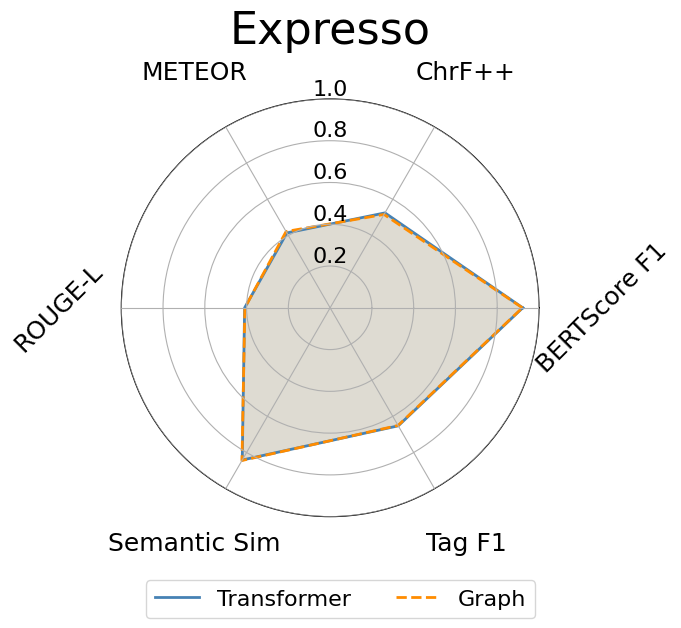

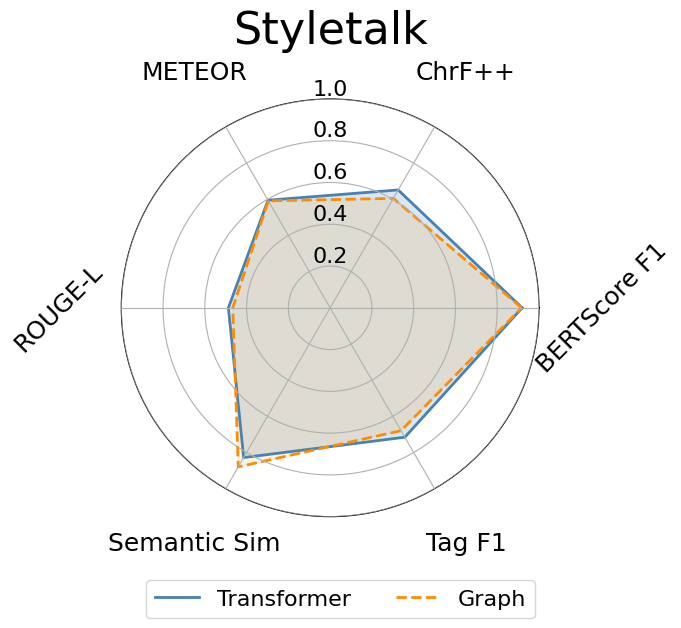

In [32]:
import numpy as np

METRICS = {
    "BERTScore F1": "bertscore_f1",
    "ChrF++": "chrf",
    "METEOR": "meteor",
    "ROUGE-L": "rougeL",
    "Semantic Sim": "pred_semantic_sim",
    "Tag F1": "tag_f1_overall",
}


def radar_plot(datasource, transformer_df, graph_df):
    labels = list(METRICS.keys())
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    def get_vals(df):
        row = df[df["test_datasource"] == datasource].iloc[0]
        vals = [float(row.get(col, float("nan"))) for col in METRICS.values()]
        return np.array(vals + vals[:1])

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.set_axisbelow(False)

    trans_vals = get_vals(transformer_df)
    graph_vals = get_vals(graph_df)

    h1, = ax.plot(angles, trans_vals, color="steelblue", linewidth=2, label="Transformer")
    ax.fill(angles, trans_vals, color="steelblue", alpha=0.2)

    h2, = ax.plot(angles, graph_vals, color="darkorange", linewidth=2, linestyle="--", label="Graph")
    ax.fill(angles, graph_vals, color="darkorange", alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    for i, (angle, label) in enumerate(zip(angles[:-1], labels)):
        rotation = 45 if i == 0 or i == 3 else 0
        ax.text(angle, 1.3, label,
                ha='center', va='center',
                rotation=rotation, fontsize=18,
                transform=ax.get_xaxis_transform())

    ax.set_ylim(0, 1)
    ax.set_rlabel_position(90)
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('center')

    ax.set_title(datasource.capitalize(), size=32, pad=40)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', pad=34)

    fig.legend(handles=[h1, h2], loc="lower center", ncol=2,
               fontsize=16, bbox_to_anchor=(0.5, -0.08), frameon=True)

    fig.subplots_adjust(top=0.75)
    plt.tight_layout()
    plt.show()

for ds in ["expresso", "styletalk"]:
    radar_plot(ds, transformer_df, graph_df)


representation collapse

In [33]:
import numpy as np

COLLAPSE_METRICS = [
    ("vec_std",      "Vector Std Dev"),
    ("mean_cosine_sim", "Mean Cosine Sim"),
]

DATASOURCES    = ["expresso", "styletalk"]
DATASET_LABELS = {"expresso": "Expresso", "styletalk": "StyleTalk"}

col_header = " & ".join(f"\\textbf{{{DATASET_LABELS[ds]}}}" for ds in DATASOURCES)
latex  = "\\begin{table}[h]\n    \\centering\n"
latex += "    \\begin{tabularx}{\\columnwidth}{Xcc}\n"
latex += "        \\toprule\n"
latex += f"        \\textbf{{Metric}} & {col_header} \\\\\n"
latex += "        \\midrule\n"

for col, label in COLLAPSE_METRICS:
    row = f"        {label}"
    for ds in DATASOURCES:
        sub = results_df[results_df["test_datasource"] == ds]
        if col in sub.columns:
            m = sub[col].dropna().astype(float).mean()
            s = sub[col].dropna().astype(float).std()
            row += f" & ${m:.3f} \\pm {s:.3f}$"
        else:
            row += " & ---"
    latex += row + " \\\\\n"

latex += "        \\bottomrule\n"
latex += "    \\end{tabularx}\n"
latex += "    \\caption{Representation collapse metrics.}\n"
latex += "    \\label{tab:representation_collapse}\n"
latex += "\\end{table}"
print(latex)


\begin{table}[h]
    \centering
    \begin{tabularx}{\columnwidth}{Xcc}
        \toprule
        \textbf{Metric} & \textbf{Expresso} & \textbf{StyleTalk} \\
        \midrule
        Vector Std Dev & $0.716 \pm nan$ & $0.398 \pm nan$ \\
        Mean Cosine Sim & $0.433 \pm nan$ & $0.764 \pm nan$ \\
        \bottomrule
    \end{tabularx}
    \caption{Representation collapse metrics.}
    \label{tab:representation_collapse}
\end{table}


energy efficiency on test set inference

Loaded runs: ['infer_graph_expresso', 'infer_graph_styletalk', 'infer_transformer_expresso', 'infer_transformer_styletalk']


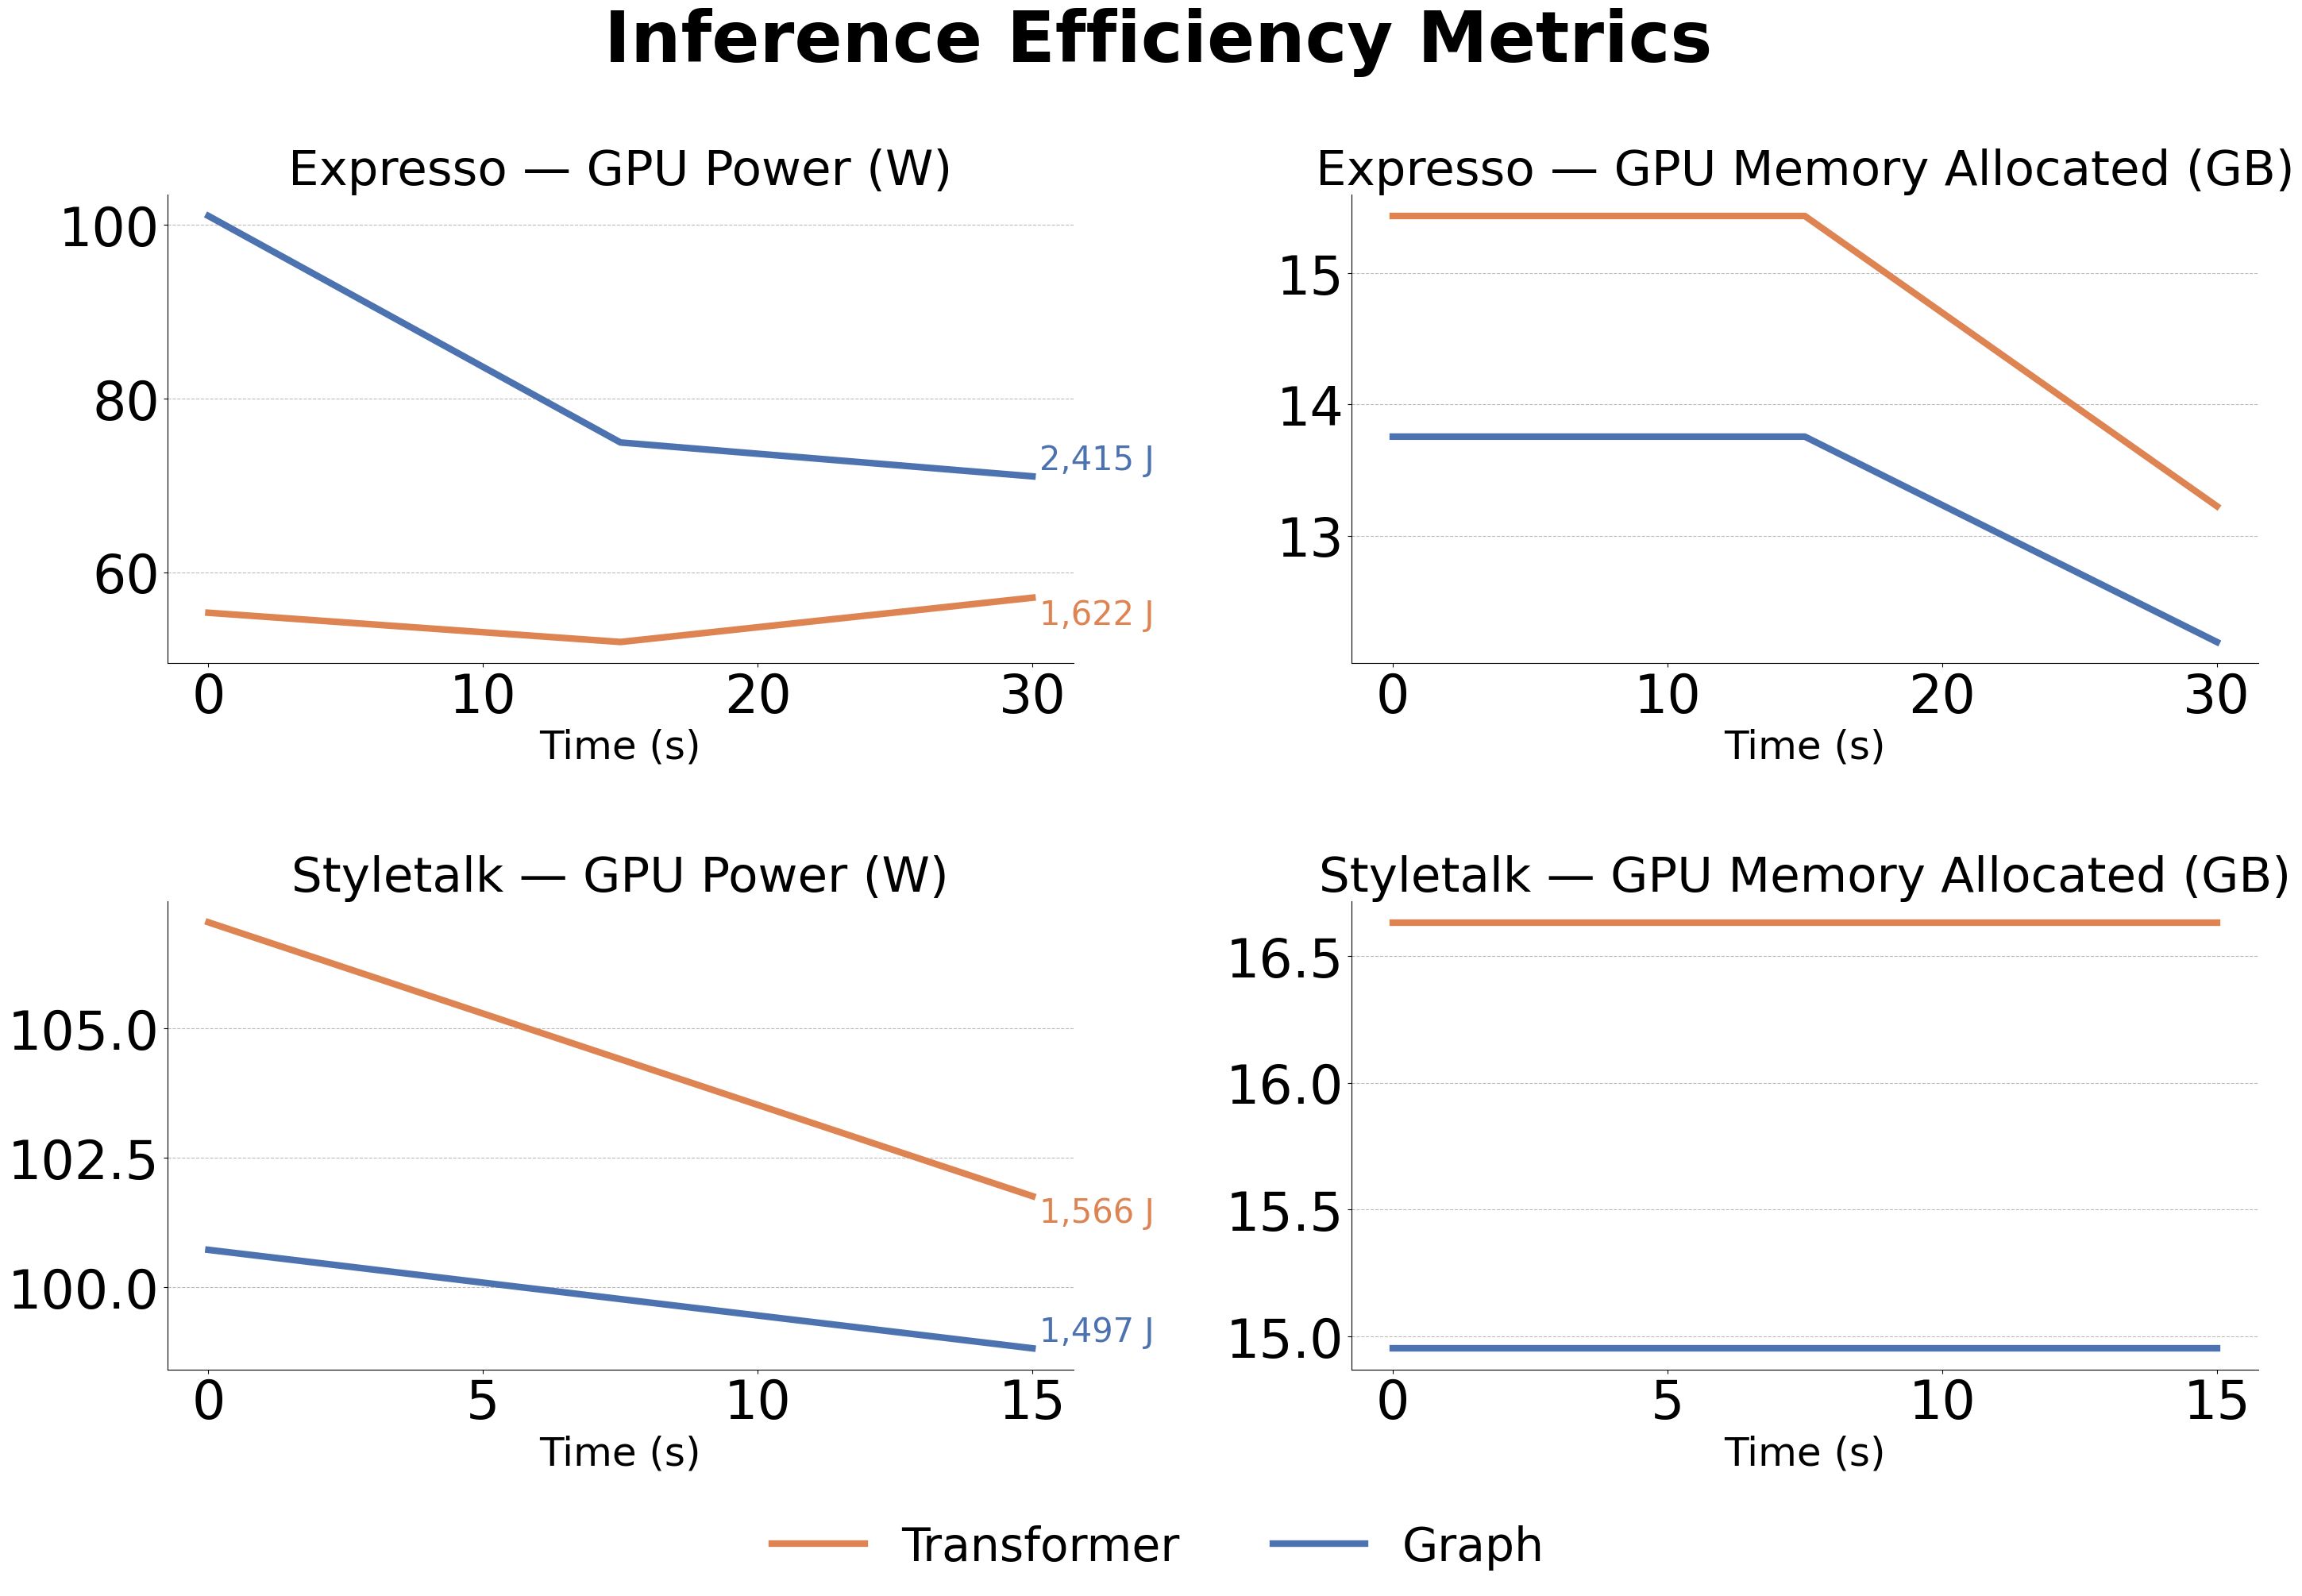

In [34]:
import re
import numpy as np

power_col = "system.gpu.0.powerWatts"
mem_col   = "system.gpu.0.memoryAllocatedBytes"

SMOOTH_SPAN       = 10
TRANSFORMER_COLOR = "#DD8452"
GRAPH_COLOR       = "#4C72B0"

DATASETS = ["expresso", "styletalk"]

all_transformer_runs = results_df["run_name"].unique().tolist()
all_graph_runs       = baseline_df["run_name"].unique().tolist()
TARGET_RUNS          = list(set(all_transformer_runs + all_graph_runs))

LINE_STYLE = {
    **{r: dict(color=TRANSFORMER_COLOR, linestyle="-", label="Transformer") for r in all_transformer_runs},
    **{r: dict(color=GRAPH_COLOR,       linestyle="-", label="Graph")       for r in all_graph_runs},
}

def smooth_with_time(df, col, span=SMOOTH_SPAN):
    sub = df[[col, "_timestamp"]].dropna(subset=[col]).reset_index(drop=True)
    elapsed = sub["_timestamp"] - sub["_timestamp"].iloc[0]
    values = sub[col].ewm(span=span, min_periods=1).mean()
    return elapsed, values

run_sys = {}

for run in api.runs(PROJECT_PATH):
    if run.name not in TARGET_RUNS:
        continue
    full_run = api.run("/".join(run.path))
    df = pd.DataFrame(full_run.history(stream="system"))
    if not df.empty:
        run_sys[run.name] = df

print(f"Loaded runs: {list(run_sys.keys())}")

fig, axes = plt.subplots(2, 2, figsize=(28, 20))

for row_idx, dataset in enumerate(DATASETS):
    transformer_runs = results_df[results_df["test_datasource"] == dataset]["run_name"].unique().tolist()
    graph_runs       = baseline_df[baseline_df["test_datasource"] == dataset]["run_name"].unique().tolist()
    dataset_runs     = transformer_runs + graph_runs

    plot_cfg = [
        (power_col, "GPU Power (W)",             axes[row_idx][0]),
        (mem_col,   "GPU Memory Allocated (GB)", axes[row_idx][1]),
    ]

    for col, ylabel, ax in plot_cfg:
        flip_joule_offset = True
        for run_name in dataset_runs:
            if run_name not in run_sys:
                continue
            df = run_sys[run_name]
            if col not in df.columns or "_timestamp" not in df.columns:
                continue

            elapsed, values = smooth_with_time(df, col)

            if col == mem_col:
                values = values / 1e9

            style = LINE_STYLE[run_name]
            ax.plot(elapsed, values, linewidth=6, **style)

            if col == power_col:
                joules = np.trapezoid(values, elapsed)
                ax.annotate(
                    f"{joules:,.0f} J",
                    xy=(elapsed.iloc[-1], values.iloc[-1]),
                    xytext=(6, 0),
                    textcoords="offset points",
                    va=("top" if flip_joule_offset else "bottom"),
                    ha="left",
                    fontsize=30, color=style["color"],
                )
                flip_joule_offset = not flip_joule_offset

        ax.set_xlabel("Time (s)", fontsize=36)
        ax.set_title(f"{dataset.capitalize()} — {ylabel}", fontsize=44)
        ax.grid(axis="y", linestyle="--", alpha=0.85)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=48)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2,
           fontsize=42, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Inference Efficiency Metrics", fontsize=64, fontweight="semibold")

plt.tight_layout(rect=[0, 0.05, 1, 0.95], w_pad=6, h_pad=8)
plt.show()


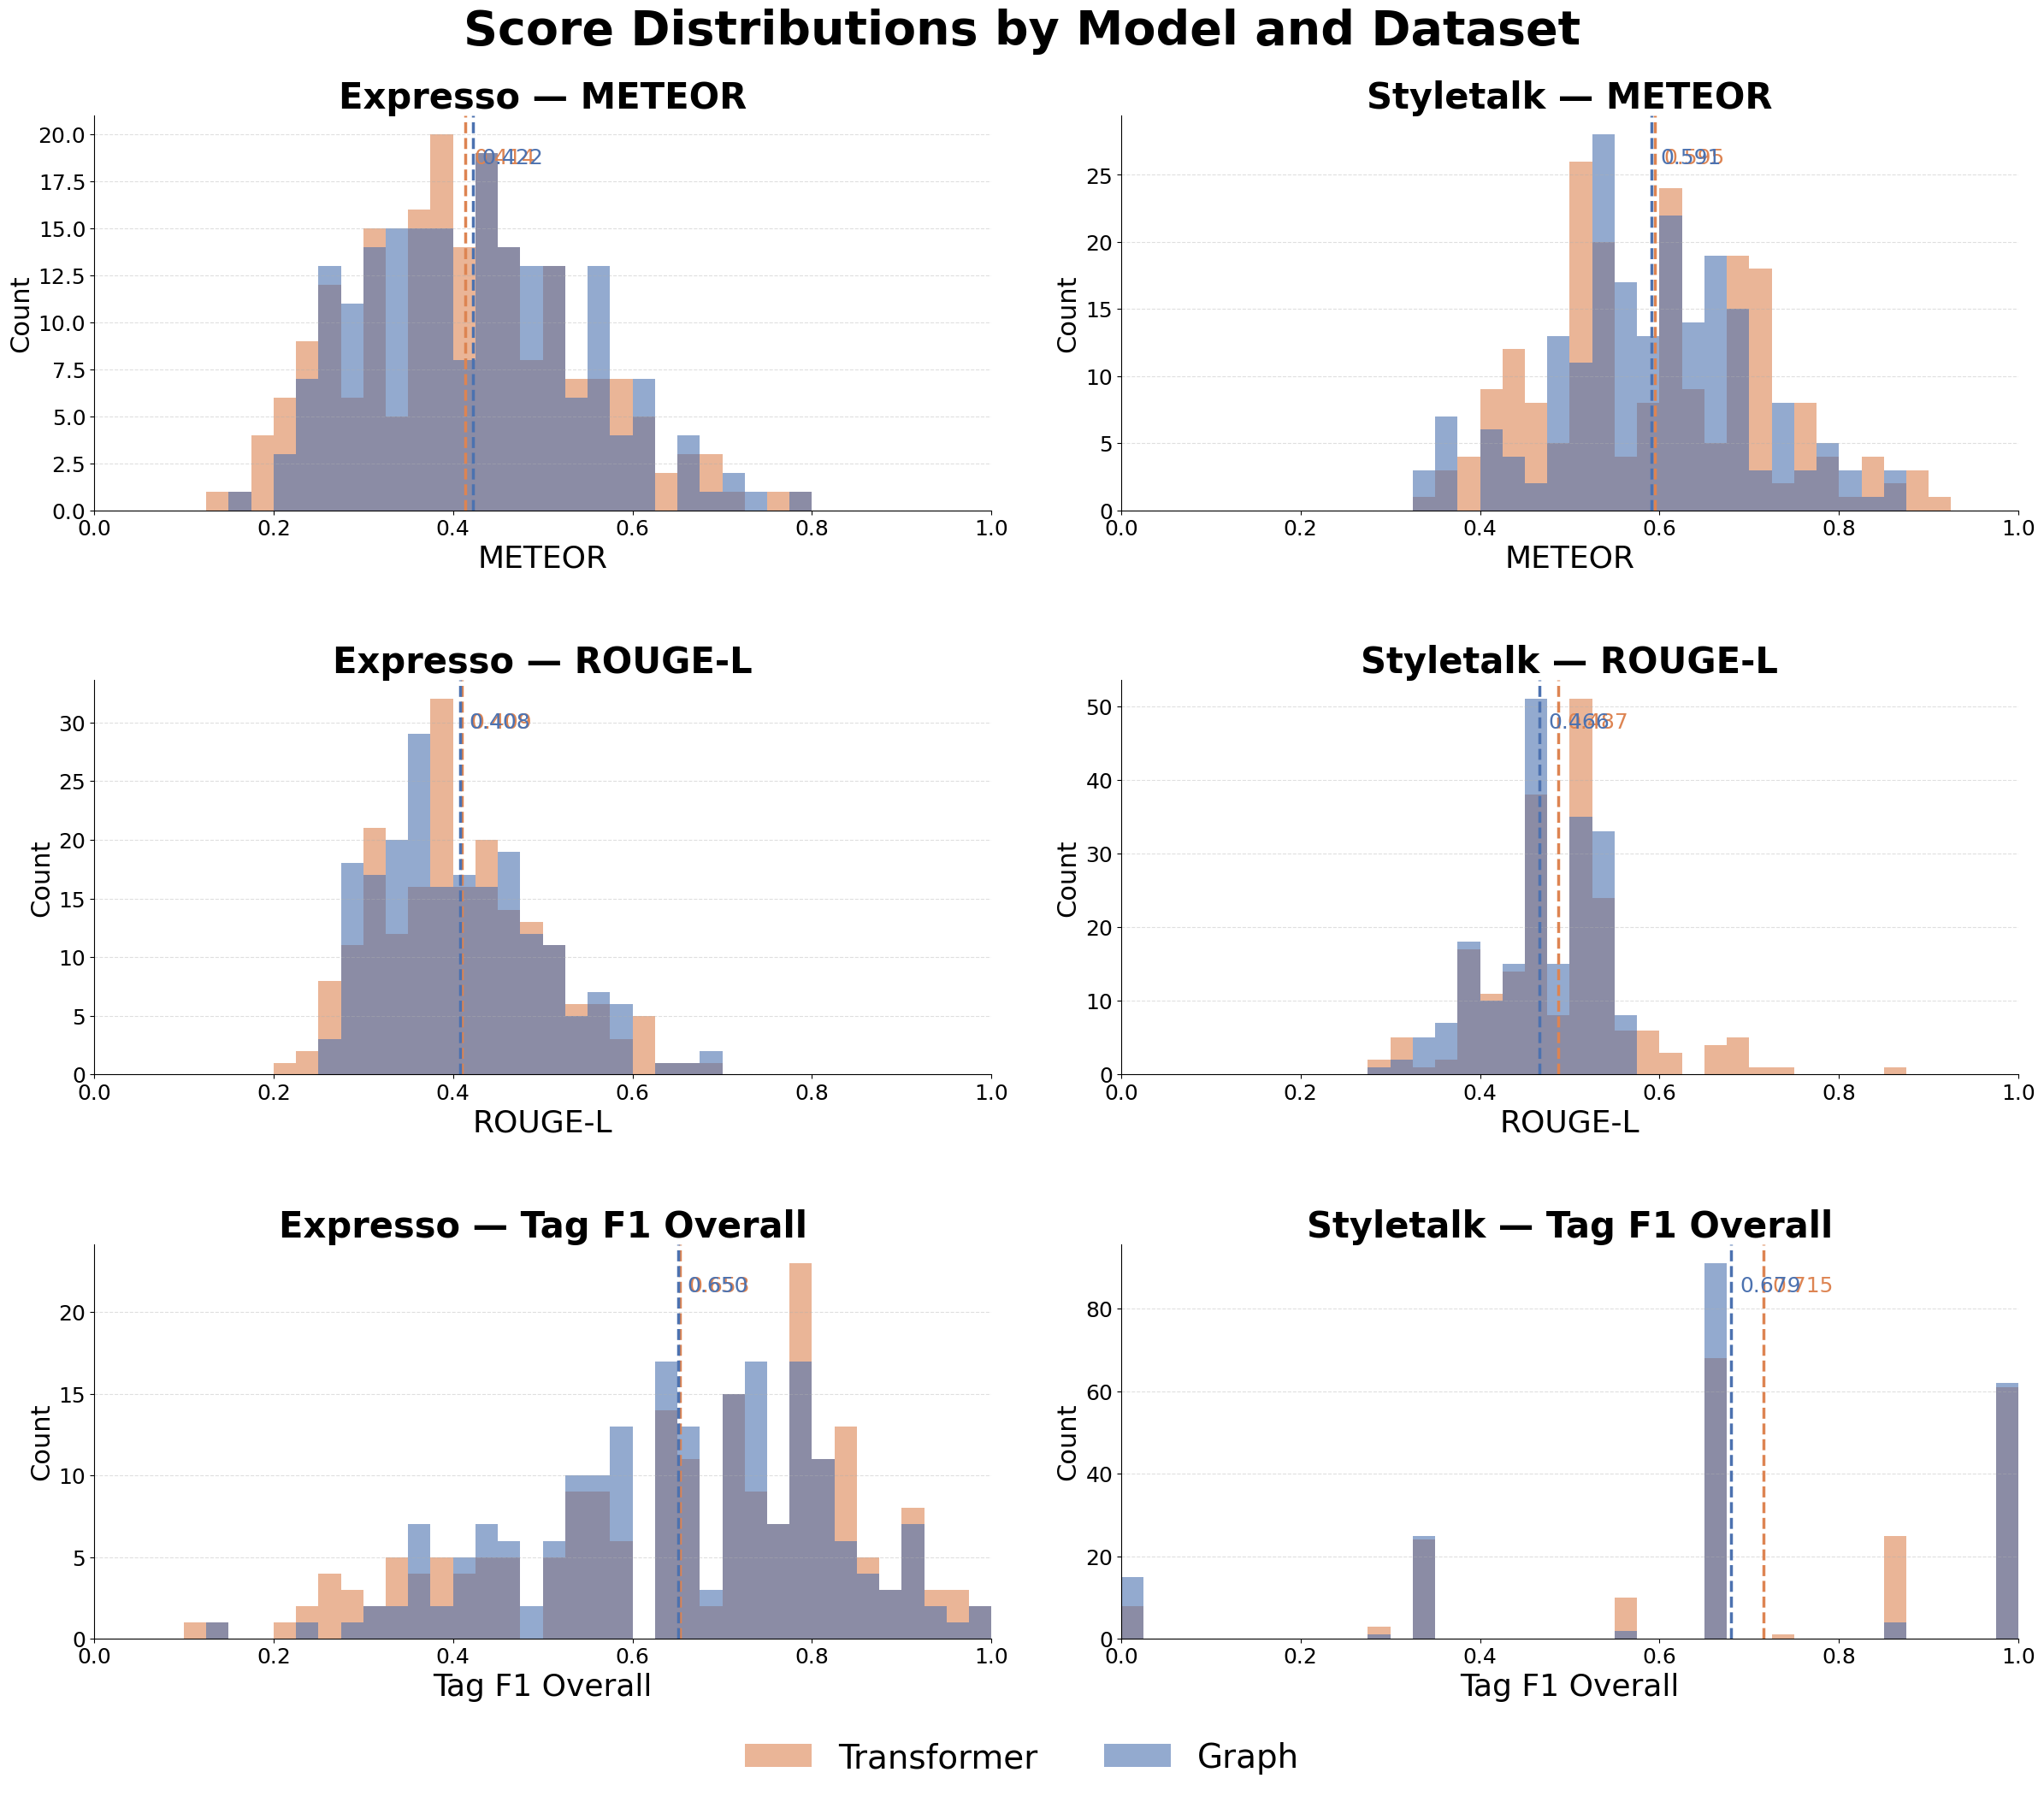

In [35]:
import numpy as np
import matplotlib.pyplot as plt

TRANSFORMER_COLOR = "#DD8452"
GRAPH_COLOR       = "#4C72B0"

DATASETS = ["expresso", "styletalk"]

METRICS = [
    ("meteor",        "METEOR"),
    ("rougeL",        "ROUGE-L"),
    ("tag_f1_overall","Tag F1 Overall"),
]

BINS = 40

fig, axes = plt.subplots(len(METRICS), len(DATASETS), figsize=(24, 7 * len(METRICS)))

for row_idx, (col, label) in enumerate(METRICS):
    for col_idx, dataset in enumerate(DATASETS):
        ax = axes[row_idx][col_idx]

        t_samples = data[f"transformer_{dataset}"]["samples"]
        g_samples = data[f"graph_{dataset}"]["samples"]

        t_vals = np.array([s[col] for s in t_samples if s[col] is not None], dtype=float)
        g_vals = np.array([s[col] for s in g_samples if s[col] is not None], dtype=float)

        bin_edges = np.linspace(0, 1, BINS + 1)

        ax.hist(t_vals, bins=bin_edges, color=TRANSFORMER_COLOR, alpha=0.6, label="Transformer")
        ax.hist(g_vals, bins=bin_edges, color=GRAPH_COLOR,       alpha=0.6, label="Graph")

        for vals, color in [(t_vals, TRANSFORMER_COLOR), (g_vals, GRAPH_COLOR)]:
            mean_val = vals.mean()
            ax.axvline(mean_val, color=color, linestyle="--", linewidth=2.5)
            ax.text(mean_val + 0.01, ax.get_ylim()[1] * 0.92,
                    f"{mean_val:.3f}", color=color, fontsize=18, va="top")

        ax.set_xlim(0, 1)
        ax.set_xlabel(label, fontsize=26)
        ax.set_ylabel("Count", fontsize=22)
        ax.set_title(f"{dataset.capitalize()} — {label}", fontsize=30, fontweight="semibold")
        ax.tick_params(axis="both", labelsize=18)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2,
           fontsize=28, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Score Distributions by Model and Dataset", fontsize=40, fontweight="semibold")
plt.tight_layout(rect=[0, 0.03, 1, 0.98], h_pad=6, w_pad=4)
plt.show()


In [36]:
import json
import os
from pathlib import Path

FAILCASE_DIR = Path("failcases")
FILES = {
    "graph_expresso":       "graph_expresso_failure_analysis.json",
    "graph_styletalk":      "graph_styletalk_failure_analysis.json",
    "transformer_expresso": "transformer_expresso_failure_analysis.json",
    "transformer_styletalk":"transformer_styletalk_failure_analysis.json",
}

CORPUS_METRICS_DISPLAY = [
    ("bertscore_f1", "BERTScore F1"),
    ("chrf",         "ChrF"),
    ("meteor",       "METEOR"),
    ("rougeL",       "ROUGE-L"),
    ("tag_f1_overall", "Tag F1"),
]

TOP_N_FAILURES = 3

SEP      = "=" * 80
SUB_SEP  = "-" * 60

data = {}
for key, fname in FILES.items():
    with open(FAILCASE_DIR / fname) as f:
        data[key] = json.load(f)

for key, d in data.items():
    run_type = d["run_type"]
    source   = d["source"]
    cm       = d["corpus_metrics"]

    print(SEP)
    print(f"  {run_type.upper()} | {source.upper()}  (n={d['n_samples']})")
    print(SEP)

    print("\nCorpus Metrics:")
    for col, label in CORPUS_METRICS_DISPLAY:
        mean = cm.get(col, float("nan"))
        std  = cm.get(f"{col}_std", float("nan"))
        print(f"  {label:<20} {mean:.4f} ± {std:.4f}")

    worst = sorted(d["samples"], key=lambda x: x["failure_rank"])[:TOP_N_FAILURES]

    print(f"\nTop {TOP_N_FAILURES} Failure Cases (rank 0 = worst):")
    for s in worst:
        print(f"\n  {SUB_SEP}")
        print(f"  Rank {s['failure_rank']}  |  Sample idx {s['idx']}")
        print(f"  BERTScore F1: {s['bertscore_f1']:.4f}  METEOR: {s['meteor']:.4f}  "
              f"ChrF: {s['chrf']:.4f}  ROUGE-L: {s['rougeL']:.4f}  Tag F1: {s['tag_f1_overall']:.4f}")

        print(f"\n  Dialogue:")
        for turn in s["dialogue"]:
            print(f"    {turn.strip()}")

        print(f"\n  Prediction : {s['prediction'].strip()}")
        print(f"  Reference  : {s['reference'].strip()}")

        print(f"\n  Missed tags       : {s['missed_tags']}")
        print(f"  Hallucinated tags : {s['hallucinated_tags']}")

        print(f"\n  Tag F1 by category:")
        for cat, score in s["tag_f1_by_category"].items():
            print(f"    {cat:<22} {score:.4f}")

    print()



  GRAPH | EXPRESSO  (n=200)

Corpus Metrics:
  BERTScore F1         0.9205 ± 0.0126
  ChrF                 0.5163 ± 0.0797
  METEOR               0.4218 ± 0.1202
  ROUGE-L              0.4082 ± 0.0900
  Tag F1               0.6505 ± 0.1641

Top 3 Failure Cases (rank 0 = worst):

  ------------------------------------------------------------
  Rank 0  |  Sample idx 83
  BERTScore F1: 0.8838  METEOR: 0.1629  ChrF: 0.3797  ROUGE-L: 0.2941  Tag F1: 0.3750

  Dialogue:
    Who is your favorite celebrity guest?
    Oh, that's a good one. I love when Harry Styles is on this year. And he was like, he was so funny. And he did the music and the acting part. It was so impressive. Yeah, how about you? Who do you like?
    That guy's so impressive, what can't he do? I forget, what was the face? It was the star of, um, um, no, Benedict Cumberbatch.

  Prediction : A male speaker with an American accent delivers a singsong, flowing speech at a slow speed, characterized by a high-pitched voice in a ve

In [52]:
VOCAB_REF = {
  "expresso": {
    "accent": [
      "american"
    ],
    "gender": [
      "female",
      "male"
    ],
    "intrinsic_tags": [
    #   "american",  excluded since already in another category
      "authoritative",
      "booming",
      "crisp",
      "enunciated",
      "flowing",
      "loud",
      "nasal",
      "shrill",
      "silky",
      "singsong"
    ],
    "situational_tags": [
        'angry',
        'animated',
        'awed',
        'bored',
        'calm',
        'confused',
        'desirous',
        'disgusted',
        'enunciated',
        # 'fast',
        'happy',
        'laughing',
        'loud',
        'passive',
        'saddened',
        'sarcastic',
        'scared',
        'sleepy',
        'sympathetic',
        'whispered'
        ],
    "noise": [
      "clean environment",
      "noisy environment",
      "environment balanced"
    ],
    "pitch": [
      "high-pitched"
    ],
    "speaking_rate": [
      "fast speed",
      "measured speed",
      "slow speed"
    ]
  },
  "styletalk": {
    "emotion": [
      "cheerful tone",
      "excited tone",
      "friendly tone",
      "hopeful tone",
      "neutral tone",
      "sad tone",
      "unfriendly tone"
    ],
    "speaking_rate": [
      "fast speed",
      "normal speed",
      "slow speed"
    ],
    "volume": [
      "loud volume",
      "normal volume",
      "quiet volume"
    ]
  }
}

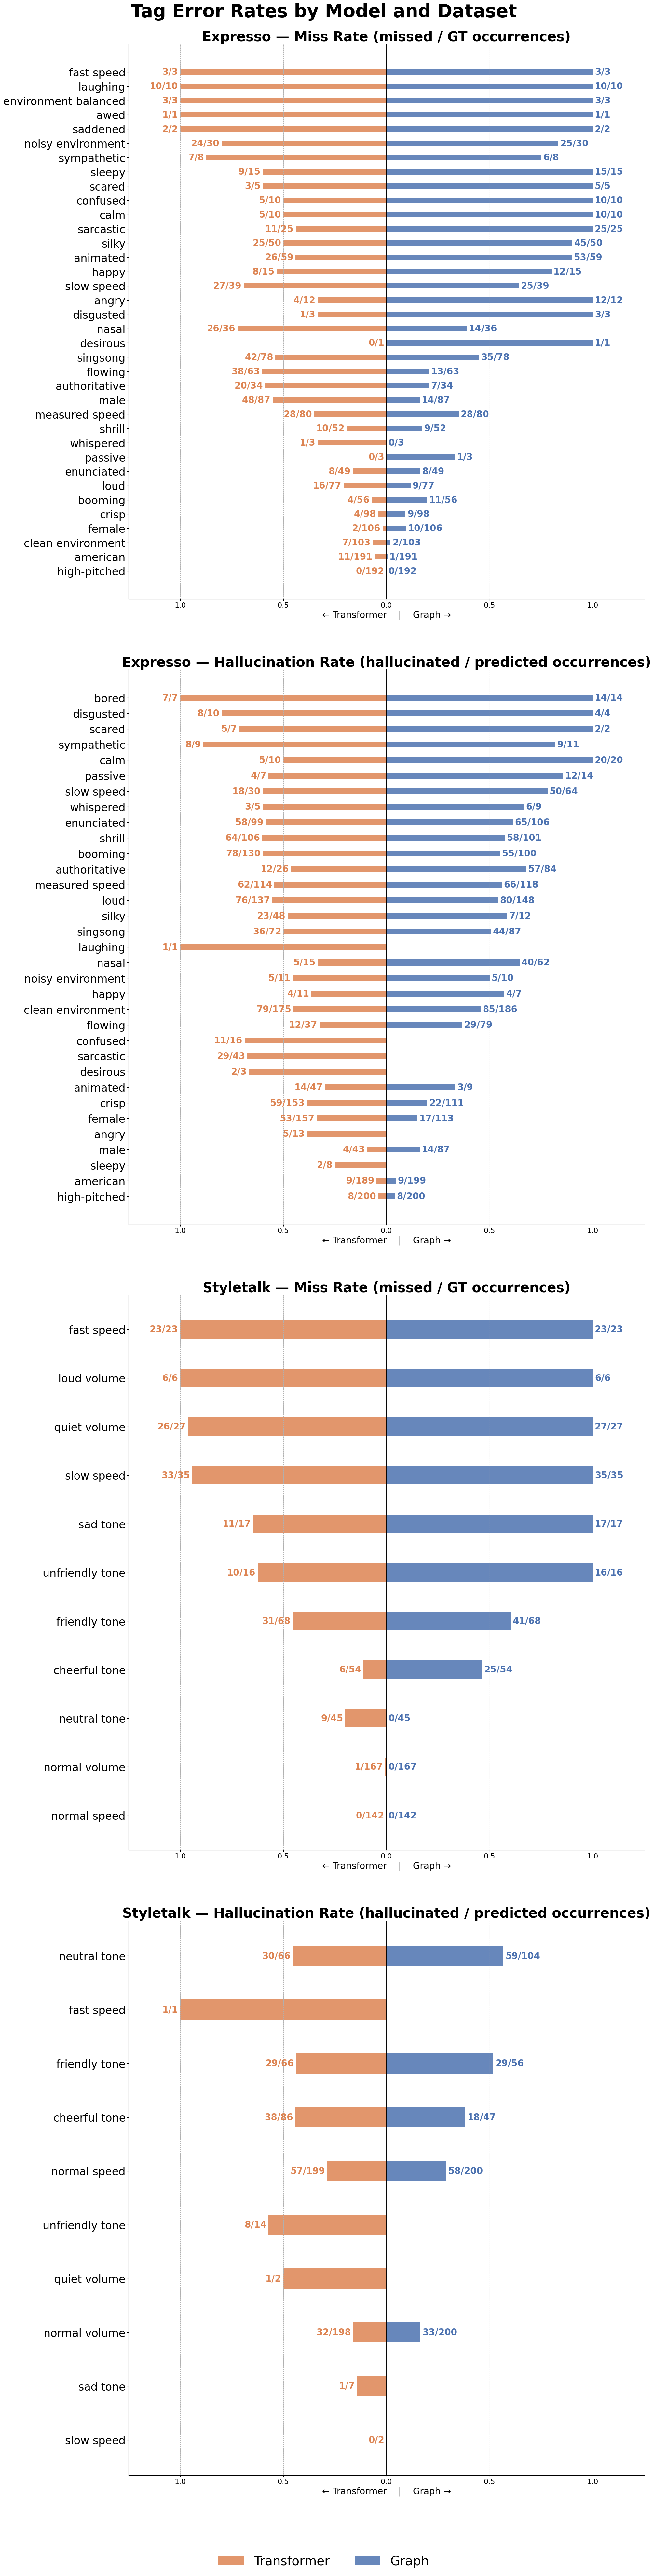

In [53]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

TRANSFORMER_COLOR = "#DD8452"
GRAPH_COLOR       = "#4C72B0"

DATASETS  = ["expresso", "styletalk"]
TAG_TYPES = [
    ("missed_tags",       "ref_tags",  "Miss Rate (missed / GT occurrences)"),
    ("hallucinated_tags", "pred_tags", "Hallucination Rate (hallucinated / predicted occurrences)"),
]

PANELS = [(ds, tag_key, denom_key, label) for ds in DATASETS for tag_key, denom_key, label in TAG_TYPES]

def tag_counts(samples, tag_key, denom_key):
    numerator   = Counter(tag for s in samples for tag in (s.get(tag_key)   or []))
    denominator = Counter(tag for s in samples for tag in (s.get(denom_key) or []))
    return {tag: (numerator.get(tag, 0), denominator[tag])
            for tag in set(numerator) | set(denominator)
            if denominator.get(tag, 0) > 0}

fig, axes = plt.subplots(len(PANELS), 1, figsize=(20, 20 * len(PANELS)))

for ax, (dataset, tag_key, denom_key, row_label) in zip(axes, PANELS):
    t_counts = tag_counts(data[f"transformer_{dataset}"]["samples"], tag_key, denom_key)
    g_counts = tag_counts(data[f"graph_{dataset}"]["samples"],       tag_key, denom_key)

    valid_tags = {tag for tags in VOCAB_REF[dataset].values() for tag in tags}
    all_tags = sorted(
        (set(t_counts) | set(g_counts)) & valid_tags,
        key=lambda tag: (t_counts.get(tag, (0, 1))[0] / t_counts.get(tag, (0, 1))[1]
                       + g_counts.get(tag, (0, 1))[0] / g_counts.get(tag, (0, 1))[1])
    )


    y      = np.arange(len(all_tags))
    height = 0.38

    t_rates = [t_counts[tag][0] / t_counts[tag][1] if tag in t_counts else 0 for tag in all_tags]
    g_rates = [g_counts[tag][0] / g_counts[tag][1] if tag in g_counts else 0 for tag in all_tags]

    bars_t = ax.barh(y, [-v for v in t_rates], height, color=TRANSFORMER_COLOR, alpha=0.85, label="Transformer")
    bars_g = ax.barh(y, g_rates,               height, color=GRAPH_COLOR,       alpha=0.85, label="Graph")

    for bar, tag in zip(bars_t, all_tags):
        if tag not in t_counts:
            continue
        n, d = t_counts[tag]
        tip = bar.get_x() + bar.get_width()
        ax.text(tip - 0.01, bar.get_y() + bar.get_height() / 2,
                f"{n}/{d}", ha="right", va="center",
                fontsize=20, color=TRANSFORMER_COLOR, fontweight="semibold")

    for bar, tag in zip(bars_g, all_tags):
        if tag not in g_counts:
            continue
        n, d = g_counts[tag]
        tip = bar.get_x() + bar.get_width()
        ax.text(tip + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{n}/{d}", ha="left", va="center",
                fontsize=20, color=GRAPH_COLOR, fontweight="semibold")

    ax.axvline(0, color="black", linewidth=1.4)
    ax.set_xlim(-1.25, 1.25)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x):.1f}"))
    ax.set_yticks(y)
    ax.set_yticklabels(all_tags, fontsize=24)
    ax.set_xlabel("\u2190 Transformer    |    Graph \u2192", fontsize=20)
    ax.set_title(f"{dataset.capitalize()} \u2014 {row_label}", fontsize=30, fontweight="semibold")
    ax.tick_params(axis="x", labelsize=16)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=1)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2,
           fontsize=28, frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Tag Error Rates by Model and Dataset", fontsize=40, fontweight="semibold")
plt.tight_layout(rect=[0, 0.02, 1, 0.98], h_pad=8)
plt.show()


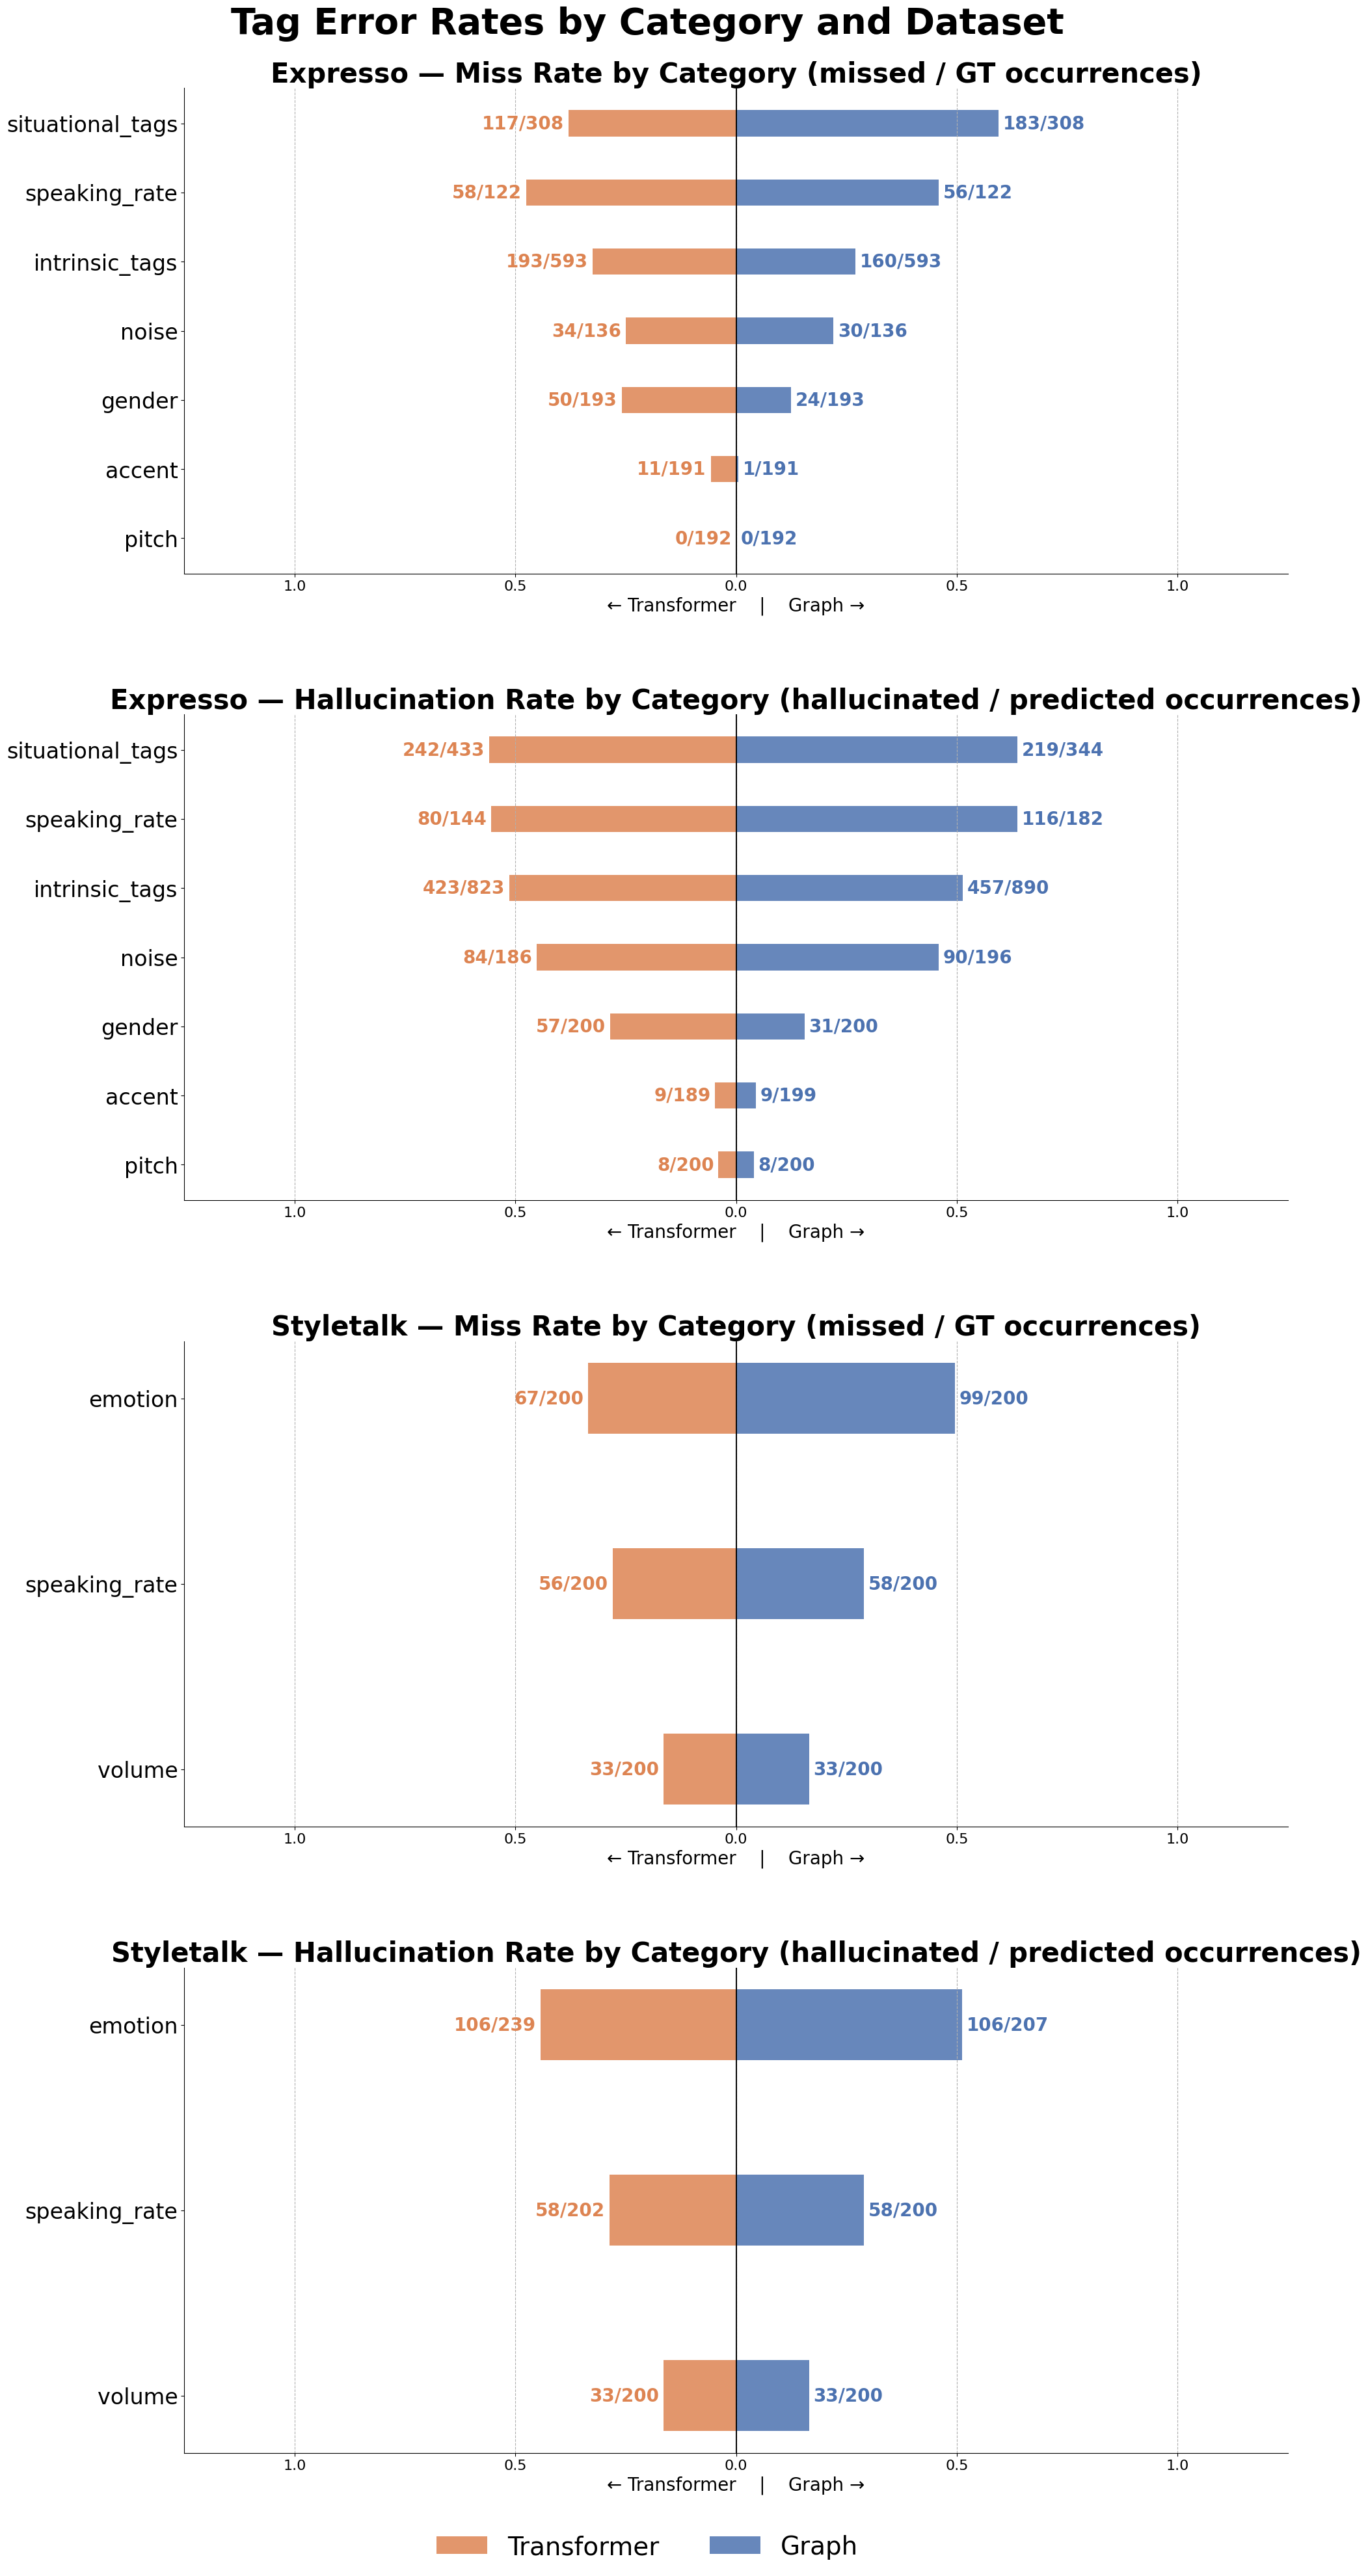

In [56]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

TRANSFORMER_COLOR = "#DD8452"
GRAPH_COLOR       = "#4C72B0"

DATASETS  = ["expresso", "styletalk"]
TAG_TYPES = [
    ("missed_tags",       "ref_tags",  "Miss Rate by Category (missed / GT occurrences)"),
    ("hallucinated_tags", "pred_tags", "Hallucination Rate by Category (hallucinated / predicted occurrences)"),
]

PANELS = [(ds, tag_key, denom_key, label) for ds in DATASETS for tag_key, denom_key, label in TAG_TYPES]

def category_counts(samples, tag_key, denom_key, dataset):
    numerator   = Counter(tag for s in samples for tag in (s.get(tag_key)   or []))
    denominator = Counter(tag for s in samples for tag in (s.get(denom_key) or []))

    result = {}
    for category, vocab in VOCAB_REF[dataset].items():
        num = sum(numerator.get(tag, 0)   for tag in vocab)
        den = sum(denominator.get(tag, 0) for tag in vocab)
        if den > 0:
            result[category] = (num, den)
    return result

fig, axes = plt.subplots(len(PANELS), 1, figsize=(20, 10 * len(PANELS)))

for ax, (dataset, tag_key, denom_key, row_label) in zip(axes, PANELS):
    t_counts = category_counts(data[f"transformer_{dataset}"]["samples"], tag_key, denom_key, dataset)
    g_counts = category_counts(data[f"graph_{dataset}"]["samples"],       tag_key, denom_key, dataset)

    all_cats = sorted(
        set(t_counts) | set(g_counts),
        key=lambda cat: (t_counts.get(cat, (0, 1))[0] / t_counts.get(cat, (0, 1))[1]
                       + g_counts.get(cat, (0, 1))[0] / g_counts.get(cat, (0, 1))[1])
    )

    y      = np.arange(len(all_cats))
    height = 0.38

    t_rates = [t_counts[cat][0] / t_counts[cat][1] if cat in t_counts else 0 for cat in all_cats]
    g_rates = [g_counts[cat][0] / g_counts[cat][1] if cat in g_counts else 0 for cat in all_cats]

    bars_t = ax.barh(y, [-v for v in t_rates], height, color=TRANSFORMER_COLOR, alpha=0.85, label="Transformer")
    bars_g = ax.barh(y, g_rates,               height, color=GRAPH_COLOR,       alpha=0.85, label="Graph")

    for bar, cat in zip(bars_t, all_cats):
        if cat not in t_counts:
            continue
        n, d = t_counts[cat]
        tip = bar.get_x() + bar.get_width()
        ax.text(tip - 0.01, bar.get_y() + bar.get_height() / 2,
                f"{n}/{d}", ha="right", va="center",
                fontsize=20, color=TRANSFORMER_COLOR, fontweight="semibold")

    for bar, cat in zip(bars_g, all_cats):
        if cat not in g_counts:
            continue
        n, d = g_counts[cat]
        tip = bar.get_x() + bar.get_width()
        ax.text(tip + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{n}/{d}", ha="left", va="center",
                fontsize=20, color=GRAPH_COLOR, fontweight="semibold")

    ax.axvline(0, color="black", linewidth=1.4)
    ax.set_xlim(-1.25, 1.25)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x):.1f}"))
    ax.set_yticks(y)
    ax.set_yticklabels(all_cats, fontsize=24)
    ax.set_xlabel("\u2190 Transformer    |    Graph \u2192", fontsize=20)
    ax.set_title(f"{dataset.capitalize()} \u2014 {row_label}", fontsize=30, fontweight="semibold")
    ax.tick_params(axis="x", labelsize=16)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=1)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2,
           fontsize=28, frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Tag Error Rates by Category and Dataset", fontsize=40, fontweight="semibold")
plt.tight_layout(rect=[0, 0.02, 1, 0.98], h_pad=8)
plt.show()
